# CBP-Vet: the data engine, end to end

Run this top to bottom and you have done a small version of what the full build did. Every
cell loads a real artifact from the real pipeline. Nothing is mocked.

It is not complete. Where a step has a long explanation behind it, this notebook makes the
point and moves on.

---

## The problem

mono-cbp searches eclipsing-binary light curves for circumbinary planets. Its search over
512 binaries produced 7,176 candidate events. Model comparison narrowed that to 1,647 that
a human had to inspect by eye, and those gave 1 real candidate. The 1,647 break down into
1,084 unmasked stellar eclipses, 258 detrending artefacts, 135 systematics and 138
nearby-binary contaminations.

That queue is the bottleneck. This project trains a model to rank it, so a human looks at
100 plots instead of 1,647 and still finds the planet.

To train one you need labelled examples of both classes, and nobody has them. About
fourteen transiting circumbinary planets are known. Fourteen is not a training set. It is
a test set, and it is used as one, sealed until the end.

So the training data has to be built. That is the data engine.

In [1]:
import os, json, warnings
warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import h5py

REPO = os.path.expanduser('~/cbp-vet')
os.chdir(REPO)
plt.rcParams.update({'figure.dpi': 110, 'font.size': 9, 'axes.grid': True,
                     'grid.alpha': 0.25, 'axes.spines.top': False, 'axes.spines.right': False})

def have(p): return os.path.exists(os.path.join(REPO, p))
print('repo:', REPO)

repo: /Users/wilsonwu/cbp-vet


---
## 1. The negatives are free

Run mono-cbp's own search over the frozen 1,946 light curves. Almost everything it flags
is a false positive. These are ordinary eclipsing binaries, and real circumbinary planets
are very rare. So the search hands us thousands of real false positives, made by the same
pipeline this vetter sits behind.

Three problems had to be fixed first, and each one fails silently. The worst is that the
cached files carry a five-name header over four data columns. That means there is no
eclipse mask, so searching them as they are runs with no masking at all.

In [2]:
ev = pd.read_csv('data/search_frozen/out/detected_events.txt', sep=r'\s+')
ev.columns = [c.lower() for c in ev.columns]
meta = json.load(open('data/search_frozen/out/run_meta.json'))
n_files = meta['n_files_searched']

print(f"light curves searched : {n_files:,}   (1 of 1,946 excluded: it is empty in the cache)")
print(f"TCEs flagged          : {len(ev):,}")
print(f"systems producing them: {ev.tic.nunique()}")
print()
print('THE REPLICATION CHECK'.center(52, '-'))
print(f"  ours     : {len(ev)/n_files:.3f} TCEs per light curve")
print(f"  mono-cbp : {7176/3808:.3f} TCEs per light curve   (7,176 over 3,808)")
print(f"  agreement: {100*abs(len(ev)/n_files - 7176/3808)/(7176/3808):.1f} % apart")

light curves searched : 1,945   (1 of 1,946 excluded: it is empty in the cache)
TCEs flagged          : 3,672
systems producing them: 518

---------------THE REPLICATION CHECK----------------
  ours     : 1.888 TCEs per light curve
  mono-cbp : 1.884 TCEs per light curve   (7,176 over 3,808)
  agreement: 0.2 % apart


That 0.2 percent agreement, on a separate set of light curves, is the evidence that the
search stage is replicated.

---
## 2. A good feature the incumbent computes and throws away

The finder groups the peaks it finds across its 21 biweight detrending windows, then
stores only `det_dep = 1 if len(group) <= 18 else 0`. The count itself is thrown away.

A real dip survives most windows. A detrending artefact survives few. So the count is a
strong free feature that was being cut down to one bit. This search never runs again, so
not saving it here would have lost it for good.

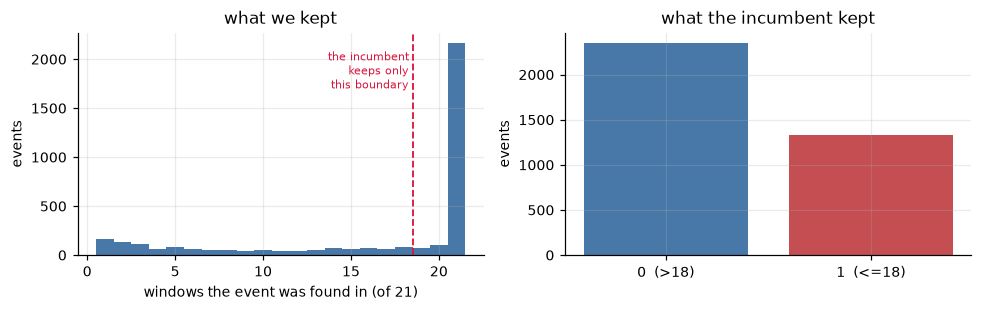

median 21, p25 12, 58.9% at the 21-window ceiling, 15.1% in <=5 windows
consistency check: det_dependence == 1 exactly when n <= 18, on every row  OK


In [3]:
n = ev.n_detrend_detections.astype(int)
fig, ax = plt.subplots(1, 2, figsize=(9, 2.9))
ax[0].hist(n, bins=np.arange(0.5, 22.5), color='#4878a8')
ax[0].axvline(18.5, color='crimson', ls='--', lw=1.2)
ax[0].set(xlabel='windows the event was found in (of 21)', ylabel='events',
          title='what we kept')
ax[0].text(18.3, ax[0].get_ylim()[1]*0.75, ' the incumbent\n keeps only\n this boundary',
           color='crimson', fontsize=7.5, ha='right')
ax[1].bar(['0  (>18)', '1  (<=18)'], ev.det_dependence.value_counts().reindex([0,1]).values,
          color=['#4878a8', '#c44e52'])
ax[1].set(ylabel='events', title='what the incumbent kept')
plt.tight_layout(); plt.show()

print(f"median {int(np.median(n))}, p25 {int(np.percentile(n,25))}, "
      f"{100*(n==21).mean():.1f}% at the 21-window ceiling, {100*(n<=5).mean():.1f}% in <=5 windows")
assert ((ev.det_dependence==1) == (n<=18)).all(), 'flag and count disagree'
print('consistency check: det_dependence == 1 exactly when n <= 18, on every row  OK')

---
## 3. The positives have to be injected

mono-cbp ships 49 transit shapes, a 7x7 grid all at impact parameter 0. Train on those and
a classifier can memorise 49 templates without learning what a transit looks like.

This bank has 16,384 profiles drawn from a Sobol sequence. Sobol is low-discrepancy, so it
spreads points evenly. Random draws clump in some places and leave holes in others. For
the same count, Sobol covers much more of the shape space.

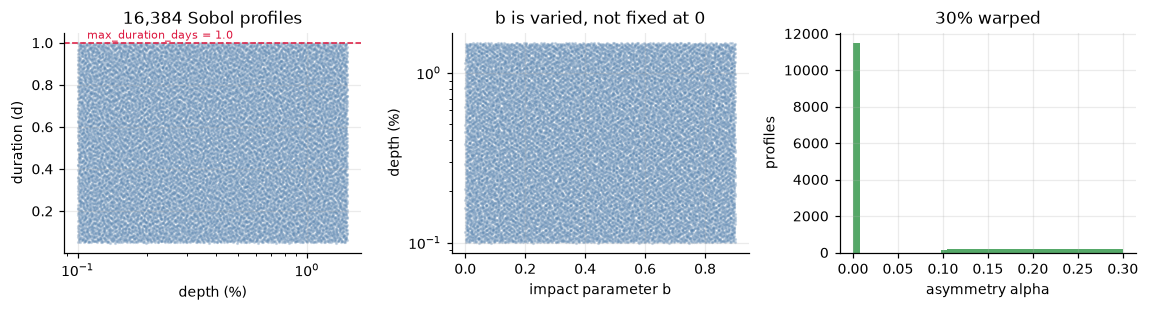

The asymmetry axis exists because a real circumbinary transit is NOT symmetric:
the star being crossed is itself moving. If every injected positive were
perfectly symmetric, "is this symmetric" would give the label away.

warp depth fidelity: OUR warp is exact to 1.7e-14 by construction; the worst-case
residual (9.2e-02) is an INHERITED mono-cbp approximation, confined to
11 near-grazing profiles at b > 0.885  [Tutorial: Chapter 2]


In [4]:
bank = pd.read_csv('data/profile_bank_v2/bank_v2_manifest.csv')
cfg  = json.load(open('data/profile_bank_v2/bank_v2_config.json'))

fig, ax = plt.subplots(1, 3, figsize=(10.5, 2.9))
ax[0].scatter(bank.depth*100, bank.duration, s=1.2, alpha=0.25, color='#4878a8')
ax[0].set(xscale='log', xlabel='depth (%)', ylabel='duration (d)', title='16,384 Sobol profiles')
ax[0].axhline(1.0, color='crimson', ls='--', lw=1)
ax[0].text(0.11, 1.02, 'max_duration_days = 1.0', color='crimson', fontsize=7)
ax[1].scatter(bank.impact_parameter, bank.depth*100, s=1.2, alpha=0.25, color='#4878a8')
ax[1].set(yscale='log', xlabel='impact parameter b', ylabel='depth (%)', title='b is varied, not fixed at 0')
w = bank[bank.asym_alpha>0]
ax[2].hist(bank.asym_alpha, bins=40, color='#55a868')
ax[2].set(xlabel='asymmetry alpha', ylabel='profiles',
          title=f'{100*(bank.asym_alpha>0).mean():.0f}% warped')
plt.tight_layout(); plt.show()

print('The asymmetry axis exists because a real circumbinary transit is NOT symmetric:')
print('the star being crossed is itself moving. If every injected positive were')
print('perfectly symmetric, "is this symmetric" would give the label away.')
print()
print('warp depth fidelity: OUR warp is exact to 1.7e-14 by construction; the worst-case')
print(f"residual ({cfg['depth_fidelity']['max_rel_error']:.1e}) is an INHERITED mono-cbp approximation, confined to")
print(f"{cfg['depth_fidelity']['n_above_5pct']} near-grazing profiles at b > "
      f"{cfg['depth_fidelity']['min_b_above_5pct']:.3f}  [Tutorial: Chapter 2]")

---
## 4. The inversion leak

To be sure a recovered injection is yours, mono-cbp flips the light curve upside down
before injecting. Real dips become bumps, so anything dip-shaped it finds must be yours.
That is the right thing to do when you are measuring completeness.

It is the wrong thing to do for training. If every positive sits in an inverted curve and
every negative in a native one, the model can learn "is this upside down" and score
perfectly while being useless on real data.

The fix runs through the whole campaign. Every provenance runs 50/50 inverted and native.
On the native half the trick no longer protects anything, so instead we mask out every
event the real search already found before drawing an epoch.

In [5]:
te = pd.read_csv('data/campaign_out/tests_all.csv')
cev = pd.read_csv('data/campaign_out/events_all.csv')

print(f"campaign: {len(te):,} tests -> {len(cev):,} events "
      f"({int((cev.label==1).sum()):,} positive)")
print(f"inversion rate: {te.inverted_lc.mean():.4f}   (gate: within 0.02 of 0.50)")
print()
print('The native-path masking fires ONLY where it is needed:')
for arm, name in [(0,'native  '), (1,'inverted')]:
    b = te[te.inverted_lc==arm].n_cadences_blocked
    print(f"   {name}: cadences blocked around known real events -> mean {b.mean():7.2f}")
print()
print('An assumption the plan carried since it was written, now closed:')
for arm, name in [(1,'inverted'), (0,'native  ')]:
    t = te[te.inverted_lc==arm]
    print(f"   {name}: {len(t):,} tests, recovery {t.recovered.mean():.4f}")
d = abs(te[te.inverted_lc==1].recovered.mean() - te[te.inverted_lc==0].recovered.mean())
print(f"   relative difference {100*d/te.recovered.mean():.2f}%  (>10% would be a datasheet item)")
print('   -> PARITY HOLDS. mono-cbp Table 3 was measured on inverted curves only.')

campaign: 65,536 tests -> 142,993 events (52,746 positive)
inversion rate: 0.4985   (gate: within 0.02 of 0.50)

The native-path masking fires ONLY where it is needed:
   native  : cadences blocked around known real events -> mean   74.49
   inverted: cadences blocked around known real events -> mean    0.00

An assumption the plan carried since it was written, now closed:
   inverted: 32,670 tests, recovery 0.6505
   native  : 32,866 tests, recovery 0.6234
   relative difference 4.25%  (>10% would be a datasheet item)
   -> PARITY HOLDS. mono-cbp Table 3 was measured on inverted curves only.


### Probe 1, and why it still fails before the remedy

Positives are 50/50 by construction. Negatives are not, and cannot be. The native arm
gives about 1.5x more negatives per test. On the native arm real dips are still dips and
get flagged; inverted, they became bumps and vanished.

That is the inversion trick working as designed, not a bug. The remedy is to subsample the
larger arm inside the negative class.

In [6]:
import sys; sys.path.insert(0, REPO)
from cbpvet.injection.rebalance import rebalance_negatives

pos, neg = cev[cev.label==1], cev[cev.label==0]
print(f"positives inverted rate : {pos.inverted_lc.mean():.4f}")
print(f"negatives inverted rate : {neg.inverted_lc.mean():.4f}")
print(f"probe-1 gap             : {abs(pos.inverted_lc.mean()-neg.inverted_lc.mean()):.4f}  "
      f"(gate <= 0.05)  -> FAIL")
print()
_, rep = rebalance_negatives(cev)
print(f"after the pre-named rebalance: gap {rep['probe1_gap_after']:.2e}  -> PASS")
print(f"negatives retained: {rep['negatives_after']:,} of {rep['negatives_before']:,} "
      f"({100*rep['negatives_after']/rep['negatives_before']:.1f}%)")

positives inverted rate : 0.5084
negatives inverted rate : 0.4084
probe-1 gap             : 0.1000  (gate <= 0.05)  -> FAIL

after the pre-named rebalance: gap 3.11e-06  -> PASS
negatives retained: 72,499 of 90,247 (80.3%)


---
## 5. Where the injections land

mono-cbp draws the epoch uniformly and requires the transit to land on real data. Each is
sensible on its own. Together they cause a problem. Real false positives cluster at gaps
and sector edges, where detrending has the least information, and near eclipses, because a
badly masked eclipse wing is the largest false-positive class there is.

So we measure where the real negatives sit in those two coordinates together, and draw
injection epochs from the same distribution. Matching each one separately would leave the
corner that is near a gap and near an eclipse too empty, and a model could still learn
it.

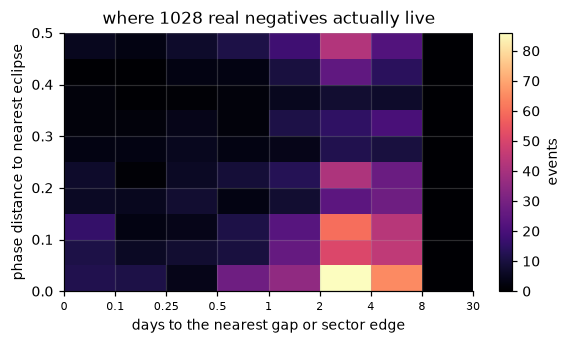

13 empty bins of 80 - the target distribution is well populated


In [7]:
h = np.load('data/search_frozen/out/joint_phase_gap_hist.npz')
H, pe, ge = h['H'], h['phase_edges'], h['gap_edges']
fig, ax = plt.subplots(figsize=(5.4, 3.2))
m = ax.pcolormesh(np.arange(len(ge)), pe, H, cmap='magma')
ax.set_xticks(np.arange(len(ge))); ax.set_xticklabels([f'{g:g}' for g in ge], fontsize=7)
ax.set(xlabel='days to the nearest gap or sector edge', ylabel='phase distance to nearest eclipse',
       title=f'where {int(h["n_events"])} real negatives actually live')
plt.colorbar(m, label='events'); plt.tight_layout(); plt.show()
print(f"{int((H==0).sum())} empty bins of {H.size} - the target distribution is well populated")

---
## 6. The 1-2 punch

Inside one conjunction a circumbinary planet can cross star 1 and then star 2, hours to
days apart, at different depths. Nothing an eclipse or an artefact does looks like that.
It is also what Kostov et al. 2020b use to pin a planet's period from well under one
orbit.

An earlier version of the plan used a fixed 1 to 4 day window. Checked against the 12
observed spacings it catches 2 of 12, and 0 of Kepler-16's 5. Kepler-16 is in the test
set. Working in `dt / P_bin` instead catches 12 of 12.

In [8]:
from cbpvet.injection import pair_model as pm
kt = pd.read_csv('data/kepler_transit_times.csv')

print('Kostov 2020b Table 1, transcribed from the PDF and cross-validated:')
print(kt.groupby('planet').agg(conjunctions=('spacing_days','size'),
                               median_spacing_d=('spacing_days','median')).to_string())
print()
r = pm.DT_OVER_PBIN
print(f"dt/P_bin across all 12: {r.min():.3f} to {r.max():.3f}, median {np.median(r):.3f}")
win14 = ((kt.spacing_days>=1)&(kt.spacing_days<=4)).sum()
print(f"the OLD fixed 1-4 d window would capture {win14} of {len(kt)}")
print(f"the per-system [0.05, 0.5] x P_bin window captures {len(kt)} of {len(kt)}")
print()
cen = json.load(open('data/elc_models/census_results.json'))
sm = json.load(open('data/elc_models/spacing_medians.json'))
print('ELC, integrating the real dynamics of 150 hosts (4,369 conjunctions),')
print(f"returns a median dt/P_bin of {sm['elc_median_dt_over_pbin']:.4f}, against Table 1's")
print(f"observed {np.median(r):.3f} and the bank's {sm['bank_median_dt_over_pbin']} - agreement with the")
print(f"published median to about {100*abs(sm['elc_median_dt_over_pbin']-0.200)/0.200:.1f} percent. The spacing model is validated.")

Kostov 2020b Table 1, transcribed from the PDF and cross-validated:
               conjunctions  median_spacing_d
planet                                       
Kepler-16 b               5            8.2200
Kepler-1647 b             1            4.3120
Kepler-34 b               4            5.1083
Kepler-35 b               2            3.1800

dt/P_bin across all 12: 0.093 to 0.383, median 0.200
the OLD fixed 1-4 d window would capture 2 of 12
the per-system [0.05, 0.5] x P_bin window captures 12 of 12

ELC, integrating the real dynamics of 150 hosts (4,369 conjunctions),
returns a median dt/P_bin of 0.1986, against Table 1's
observed 0.200 and the bank's 0.1953 - agreement with the
published median to about 0.7 percent. The spacing model is validated.


---
## 7. ELC, positives with real physics

Every bank profile is a batman transit pasted on at a time we picked. It knows nothing
about the binary, cannot say which star was crossed, and cannot make a real punch.

ELC integrates the actual orbits. With `iwriteeclipse = 1` it writes the exact time of
every transit for each star, labelled by which body crossed which star. So same-star
versus cross-star, and the three-part depth-ratio screen, are measured instead of assumed.

ELC is never modified. The driver reads the template, copies the binary into a scratch
directory, and a fingerprint guard SHA256s all 110 distribution files before and after
every run.

In [9]:
elc = pd.read_csv('data/elc_models/pilot/elc_manifest.csv')
pilot = json.load(open('data/elc_batch/pilot/elc_batch_summary.json'))
full = json.load(open('data/elc_batch/full/elc_batch_summary.json'))

print(f"{len(elc)} pilot ELC models over {elc.tic.nunique()} hosts, "
      f"{(elc.qa_status=='PASS').sum()} passed QA, 0 broken; "
      f"sigma allocation {100*(elc.sigma_bin=='low').mean():.1f}% tight-coplanarity (rule >= 60%)")
print()
print("PER-STAR RECOVERY - the mentor's depth-ratio screen, measured TWICE:")
print('  (the screen: a planet crossing the fainter star makes a shallower dip,')
print('   so its transits are systematically harder to recover)')
for name, s in (('3-host pilot (best hosts)   ', pilot),
                ('147-of-150-host POPULATION ', full)):
    r1, r2 = s['per_star_recovery']['1'], s['per_star_recovery']['2']
    print(f"   {name}: star1 {r1['recovery']:.4f}  star2 {r2['recovery']:.4f}  "
          f"ratio {r2['recovery']/r1['recovery']:.2f}")
print('   QUOTE THE POPULATION ROW. The pilot is the best case, and the gap between')
print('   the rows is itself the finding: the screen bites harder on typical systems.')
print()
cen = json.load(open('data/elc_models/census_results.json'))
print('PAIR RATE, like for like (population values; pilot best-case in parentheses):')
print(f"   ELC geometric               {cen['geometric_pair_rate']:.4f}")
print(f"   ELC detected | geometric    {full['detected_pair_rate']:.4f}   ({pilot['detected_pair_rate']:.4f} on the 3 best hosts)")
print(f"   => ELC detected fraction    {cen['geometric_pair_rate']*full['detected_pair_rate']:.4f}")
print(f"   bank geometric (Chen & Kipping f2)   0.37")
print()
print('THE CORRECTION, told on ourselves: an earlier measurement said 0.6275 and')
print('"the bank is 3.7x too low". That was wrong: it counted grazing conjunctions')
print('(|b| >= 1, vanishing width) as transits. Corrected, ELC geometric is 0.3323')
print('vs the bank\'s 0.37 - the bank was right all along, and the census PASSES')
print('(delta 0.038, no trip).  [Tutorial: Chapter 7]')

72 pilot ELC models over 3 hosts, 72 passed QA, 0 broken; sigma allocation 62.5% tight-coplanarity (rule >= 60%)

PER-STAR RECOVERY - the mentor's depth-ratio screen, measured TWICE:
  (the screen: a planet crossing the fainter star makes a shallower dip,
   so its transits are systematically harder to recover)
   3-host pilot (best hosts)   : star1 0.7925  star2 0.5556  ratio 0.70
   147-of-150-host POPULATION : star1 0.4800  star2 0.2274  ratio 0.47
   QUOTE THE POPULATION ROW. The pilot is the best case, and the gap between
   the rows is itself the finding: the screen bites harder on typical systems.

PAIR RATE, like for like (population values; pilot best-case in parentheses):
   ELC geometric               0.3323
   ELC detected | geometric    0.1754   (0.5000 on the 3 best hosts)
   => ELC detected fraction    0.0583
   bank geometric (Chen & Kipping f2)   0.37

THE CORRECTION, told on ourselves: an earlier measurement said 0.6275 and
"the bank is 3.7x too low". That was wrong: 

---
## 8. What one event looks like to a model

Three parts. A local view [2, 201] of the event with a validity mask. A recurrence view
[2, 64] that stacks other binary cycles at the same phase. And 39 stored scalars, 37 of
which are offered to models, including the incumbent's own 17 columns. Injection truth was
moved to `truth_*` audit columns after the leak fix.

The recurrence view answers the question the incumbent cannot. Does anything happen at
this same orbital phase in other cycles? A stellar eclipse repeats every cycle. A planet
does not.

It is cut from the original cached light curve, never from the injected or inverted array.
That is what makes it sign-invariant, so the inversion leak cannot get in through the back
door. Two unit tests check this.

using shard: data/bench/full/bench_full.h5
188,732 records | local (188732, 2, 201) | recurrence (188732, 2, 64)


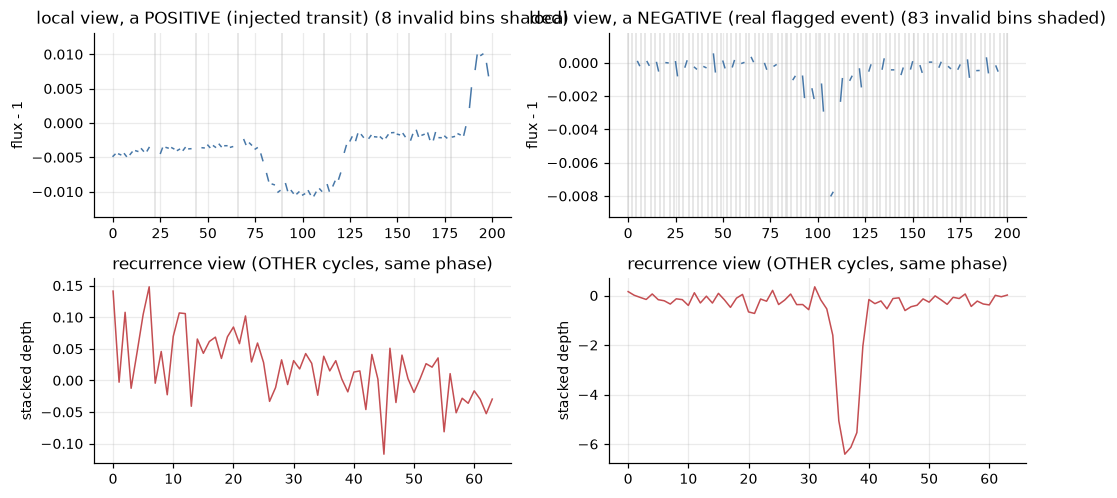

channel 1 of the local view is a validity mask: gaps are DECLARED, not filled with
zeros, because a zero-filled gap reads as a 100% transit.


In [10]:
shard = 'data/bench/full/bench_full.h5' if have('data/bench/full/bench_full.h5') else 'data/bench/pilot/bench_pilot.h5'
print('using shard:', shard)
with h5py.File(shard) as f:
    loc, rec = f['local'][:], f['recurrence'][:]
    lab = f['scalars']['label'][:]
    src = f['scalars']['label_source'][:]
print(f"{len(lab):,} records | local {loc.shape} | recurrence {rec.shape}")

i_pos = int(np.where(lab==1)[0][0]); i_neg = int(np.where(lab==0)[0][0])
fig, ax = plt.subplots(2, 2, figsize=(9.5, 4.6))
for col, (i, name) in enumerate([(i_pos,'a POSITIVE (injected transit)'), (i_neg,'a NEGATIVE (real flagged event)')]):
    valid = loc[i,1] > 0.5
    flux = np.where(valid, loc[i,0], np.nan)   # invalid cadences DRAWN AS GAPS, never as zeros
    ax[0,col].plot(flux, lw=1, color='#4878a8')
    lo, hi = np.nanmin(flux), np.nanmax(flux); pad = 0.15*(hi-lo+1e-12)
    ax[0,col].fill_between(range(loc.shape[2]), lo-pad, hi+pad, where=~valid,
                           color='0.88', zorder=0)
    ax[0,col].set(title=f'local view, {name} ({(~valid).sum()} invalid bins shaded)',
                  ylabel='flux - 1', ylim=(lo-pad, hi+pad))
    ax[1,col].plot(rec[i,0], lw=1, color='#c44e52')
    ax[1,col].set(title='recurrence view (OTHER cycles, same phase)', ylabel='stacked depth')
plt.tight_layout(); plt.show()
print('channel 1 of the local view is a validity mask: gaps are DECLARED, not filled with')
print('zeros, because a zero-filled gap reads as a 100% transit.')

---
## 9. The seven probes

A benchmark built from injections can look excellent and be worthless. Every choice made
while building the positives is a chance to leave a mark that separates the classes for a
reason that has nothing to do with planets. That mark would sit in train, validation and
test alike, so a normal workflow would never show it.

So before the dataset can freeze, we try to cheat it on purpose. The pass condition is
backwards from normal machine learning. A probe must FAIL to predict. The gate is
validation ROC-AUC at most 0.55, and splits are always grouped by TIC.

In [11]:
pr_path = ('data/bench/full/probe_results.json' if have('data/bench/full/probe_results.json')
           else 'data/bench/pilot/probe_results.json')
pr = json.load(open(pr_path))
print(f"probe results: {pr_path}  (scale: {pr['scale']}, provisional={pr['provisional']})")
print()
for p in pr['probes']:
    v = p.get('value'); vs = ' n/a ' if v is None else f"{v:.4f}"
    verdict = 'SKIP' if p.get('pass') is None else ('PASS' if p['pass'] else 'FAIL')
    print(f"  probe {p['probe']}  {p['name'][:46]:48s} {vs}  {verdict}")
    if p.get('note'): print(f"           note: {p['note'][:90]}")
print()
print(f"MDE {pr['mde_absolute']:.4f} on {pr['n_tics']} distinct TICs against a {pr['mde_target']} target -> ADEQUATE")
print('The plan predicted this would exceed the target (at pilot scale it did: 0.1665);')
print('at full scale it does NOT, so the pre-named stratum widening never fired.')
print('Counting EVENTS instead of systems would overstate power badly.')

probe results: data/bench/full/probe_results.json  (scale: full, provisional=False)

  probe 1  inversion balance                                0.0000  PASS
  probe 2  provenance (bank vs ELC)                         0.8568  FAIL
  probe 3  eclipse-phase distance                           0.5223  PASS
  probe 4  host identity                                    0.1752  FAIL
  probe 5  observed binary-cycle coverage                   0.5054  PASS
  probe 6  distance to the nearest gap or sector edge       0.5694  FAIL
  probe 7  event depth [REPORTED ONLY, never gated]         0.3810  SKIP

MDE 0.0810 on 583 distinct TICs against a 0.1 target -> ADEQUATE
The plan predicted this would exceed the target (at pilot scale it did: 0.1665);
at full scale it does NOT, so the pre-named stratum widening never fired.
Counting EVENTS instead of systems would overstate power badly.


---
## 10. The head-to-head against the incumbent

Everything above built and defended a dataset. This is the comparison against mono-cbp's
own vetting. It ran once, on the frozen test split, under rules fixed before anyone saw a
test number.

The idea is simple. Fix the incumbent's sensitivity, then count how much junk each method
sends to a human. Same positives, same negatives, same denominator, so the only thing that
varies is how well each method ranks.

The incumbent has two operating points, read from its own source rather than assumed.

- **OP-A, thresholds only.** SNR >= 5, duration <= 1 day, detrending-dependence pass, Skye
  pass.
- **OP-B, thresholds plus model comparison.** OP-A, and the best of its four fitted models
  is transit or ambiguous transit. AT means the transit model won but fit poorly on the
  residual test. This is the full published pipeline, the one that produced the
  1,647-event queue. Its measured stratum recall is 0.345, so its own model-comparison
  step throws away two thirds of true shallow transits. That gap is where a learned ranker
  has room to help, and it is measured, not assumed.

One detail worth writing down. The Skye flag is a per-sector statistic of the real search,
so it is undefined for injected events. Undefined counts as PASS. That matches how the
incumbent's own completeness numbers are measured on injections, and the choice is
recorded rather than left silent.

Two feature models were trained on the frozen shard and picked on validation PR-AUC alone.
The test split stayed untouched until the final table.

- **arm b0**, the incumbent's own 17 columns and nothing else. This is the validity check.
  If the harness is fair, a model given only the incumbent's information should roughly
  match the incumbent, not beat it.
- **arm b**, all 37 offered scalars. The same 17, plus the core event and context scalars
  and the gated observed-pair features.

The matched-recall harness works on the test split's positives, pooled and on the 0.15 to
0.30 percent depth stratum where the real hunt happens. Measure the incumbent's recall,
set the model's threshold to match it exactly, then count false positives on the real
search's test negatives. Those are real junk, not injections. Uncertainty comes from a
bootstrap that resamples whole systems, because events from one binary are not
independent.

In [12]:
t0 = json.load(open('data/bench/full/t0_core.json'))
add = json.load(open('data/bench/full/t0_addendum_2026-08-06.json'))

print('M0 - THE INCUMBENT, measured on the frozen test split')
for op in ('A', 'B'):
    m = t0['m0'][op]
    print(f"  OP-{op}: recall pooled {m['recall_pooled']:.3f} | "
          f"stratum {m['recall_stratum']:.3f} | real FPs flagged {m['real_fp_flagged']}")
print()
print('M1 - THE GRID, selected on validation PR-AUC only (test untouched here)')
for arm in ('b0', 'b'):
    g = t0['m1_grid'][arm]
    row = '  '.join(f"{k} {v['val_pr_auc']:.4f}" for k, v in g['scores'].items())
    print(f"  arm {arm:3s} ({g['n_features']:2d} features): {row}  -> {g['selected']}")
print()
print('T0 - THE BANKED TABLE (OP-B, 0.15-0.30% depth stratum, matched recall)')
for arm in ('b0', 'b'):
    c = t0['t0_matched_recall'][arm]['OPB_stratum']
    print(f"  arm {arm:3s}: {c['queue_fp_only']:3d} FPs at the incumbent's recall "
          f"{c['m0_recall']:.3f}   (incumbent itself: 65)")

# The headline, recomputed from raw counts, not transcribed:
fp_m0  = t0['m0']['B']['real_fp_flagged']
fp_b   = t0['t0_matched_recall']['b']['OPB_stratum']['queue_fp_only']
fp_b0  = t0['t0_matched_recall']['b0']['OPB_stratum']['queue_fp_only']
ci     = t0['t0_matched_recall']['b']['OPB_stratum']['fp_ci_2p5_97p5']
n_test, n_real = t0['n_test_files'], t0['n_real_test_files']
assert fp_m0 == 65 and fp_b == 8
print()
print(f"HEADLINE: {fp_m0} -> {fp_b} manual-inspection FPs = {fp_m0/fp_b:.2f}x queue reduction")
print(f"  per 1,000 test-split files      (n={n_test}): {1000*fp_m0/n_test:.1f} -> {1000*fp_b/n_test:.1f}")
print(f"  per 1,000 real-negative files   (n={n_real}): {1000*fp_m0/n_real:.1f} -> {1000*fp_b/n_real:.1f}")
print(f"  bootstrap CI on the model rate: [{ci[0]:.1f}, {ci[1]:.1f}] per 1,000 real-negative files")
print(f"VALIDITY CHECK: arm b0 (incumbent info only) flags {fp_b0} vs the incumbent's {fp_m0}")
print('  -> it REPRODUCES the incumbent instead of beating it. The 8x is not a harness artifact;')
print('     it appears exactly when the model receives features the incumbent does not use.')

M0 - THE INCUMBENT, measured on the frozen test split
  OP-A: recall pooled 0.748 | stratum 0.739 | real FPs flagged 124
  OP-B: recall pooled 0.397 | stratum 0.345 | real FPs flagged 65

M1 - THE GRID, selected on validation PR-AUC only (test untouched here)
  arm b0  (17 features): logreg 0.5377  rf 0.6991  xgboost 0.7140  -> xgboost
  arm b   (37 features): logreg 0.7702  rf 0.8731  xgboost 0.8857  -> xgboost

T0 - THE BANKED TABLE (OP-B, 0.15-0.30% depth stratum, matched recall)
  arm b0 :  63 FPs at the incumbent's recall 0.345   (incumbent itself: 65)
  arm b  :   8 FPs at the incumbent's recall 0.345   (incumbent itself: 65)

HEADLINE: 65 -> 8 manual-inspection FPs = 8.12x queue reduction
  per 1,000 test-split files      (n=365): 178.1 -> 21.9
  per 1,000 real-negative files   (n=251): 259.0 -> 31.9
  bootstrap CI on the model rate: [4.0, 71.8] per 1,000 real-negative files
VALIDITY CHECK: arm b0 (incumbent info only) flags 63 vs the incumbent's 65
  -> it REPRODUCES the incumb

### The dual, the same result read the other way

Matched recall answers "same sensitivity, how much less junk?". The mirror question is
"same junk budget, how much more sensitivity?". If only one direction looked good, the
threshold choice would be doing the work. Both were computed. The dual is part of the
pre-registered harness, and `experiments/21_freeze_models.py` finished it. That script
refuses to write until the retrained models reproduce every banked number exactly.

One lesson about denominators, learned by getting it wrong. The banked table divided its
per-1,000 rates by real-negative files (251). The pinned convention divides by all
test-split files (365). The ratio is the same either way, because the 65 and the 8 are
counted on the same negatives, but the absolute rates differ. So every surface now quotes
one convention and says which. The correction sits in `ERRATA_bench-v1.md` next to the
freeze, not as an edit to a frozen file.

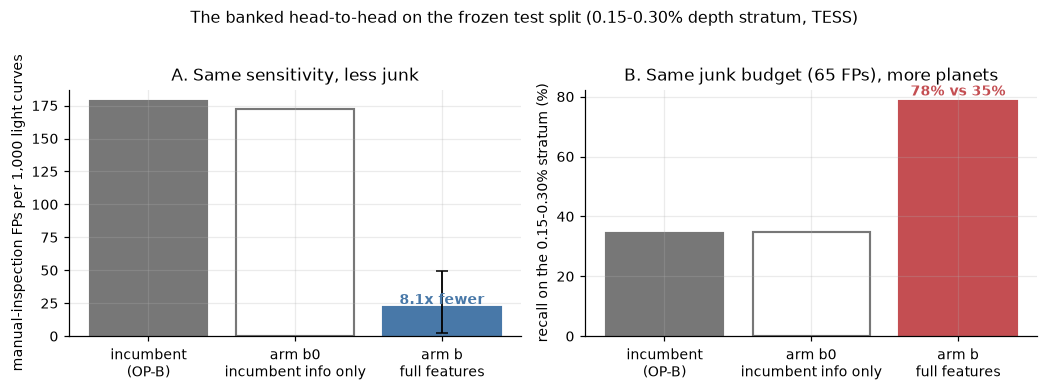

Read the two panels together: the hollow bar (arm b0) tracks the incumbent in BOTH,
which is the fairness check; the filled bars move only because of the added features.
Panel A denominator: all 365 test-split (TIC, sector) files (the pinned convention).


In [13]:
# The headline figure: both directions of the same frozen comparison.
d = add['dual_recall_at_m0_matched_fp']
n_test = t0['n_test_files']

fig, ax = plt.subplots(1, 2, figsize=(9.6, 3.4))

# Panel A: junk per 1,000 light curves at the incumbent's sensitivity
vals_a = [1000*fp_m0/n_test, 1000*fp_b0/n_test, 1000*fp_b/n_test]
ci_lo = ci[0]*n_real/n_test; ci_hi = ci[1]*n_real/n_test   # convert CI to the pinned denominator
bars = ax[0].bar(['incumbent\n(OP-B)', 'arm b0\nincumbent info only', 'arm b\nfull features'],
                 vals_a, color=['#777777', 'none', '#4878a8'],
                 edgecolor=['#777777', '#777777', '#4878a8'], linewidth=1.4)
ax[0].errorbar(2, vals_a[2], yerr=[[vals_a[2]-ci_lo], [ci_hi-vals_a[2]]],
               fmt='none', ecolor='k', capsize=4, lw=1.2)
ax[0].set(ylabel='manual-inspection FPs per 1,000 light curves',
          title='A. Same sensitivity, less junk')
ax[0].text(2, vals_a[2]+ci_hi*0.05, f'{fp_m0/fp_b:.1f}x fewer', ha='center',
           fontsize=9, fontweight='bold', color='#4878a8')

# Panel B: sensitivity at the incumbent's junk budget (the dual)
rec_m0 = d['b']['OPB_stratum']['m0_recall_same_cell']
rec_b0 = d['b0']['OPB_stratum']['model_recall_at_m0_fp']
rec_b  = d['b']['OPB_stratum']['model_recall_at_m0_fp']
ax[1].bar(['incumbent\n(OP-B)', 'arm b0\nincumbent info only', 'arm b\nfull features'],
          [100*rec_m0, 100*rec_b0, 100*rec_b], color=['#777777', 'none', '#c44e52'],
          edgecolor=['#777777', '#777777', '#c44e52'], linewidth=1.4)
ax[1].set(ylabel='recall on the 0.15-0.30% stratum (%)',
          title=f'B. Same junk budget ({fp_m0} FPs), more planets')
ax[1].text(2, 100*rec_b+2, f'{100*rec_b:.0f}% vs {100*rec_m0:.0f}%', ha='center',
           fontsize=9, fontweight='bold', color='#c44e52')

fig.suptitle('The banked head-to-head on the frozen test split '
             '(0.15-0.30% depth stratum, TESS)', y=1.03, fontsize=10.5)
plt.tight_layout(); plt.show()

print('Read the two panels together: the hollow bar (arm b0) tracks the incumbent in BOTH,')
print('which is the fairness check; the filled bars move only because of the added features.')
print(f'Panel A denominator: all {n_test} test-split (TIC, sector) files (the pinned convention).')

### Why this number can be trusted

1. **The test split was touched once**, at this table. Selection happened on validation
   PR-AUC alone, and the frozen by-TIC split ships inside the shard, hashed.
2. **The negatives are real.** Every false positive counted here is an event mono-cbp's
   own search flagged on a real light curve. No injected junk inflates the incumbent's
   side.
3. **The validity arm matches the incumbent.** Arm b0, given only the incumbent's own 17
   columns, lands at the incumbent's level in both panels. A rigged harness would have let
   it win too.
4. **The probes gate the inputs.** Every feature the model saw survived the leak probes in
   section 9. The two that could not be certified clean, `gap_proximity` and `skye_flag`,
   were withheld from every arm.
5. **The models are frozen.** Both selected XGBoost models are checkpointed with SHA-256
   hashes in `data/bench/full/models/`, and the one-shot on real planets has to assert
   those hashes before scoring. So the model that produced this table is provably the one
   tested against the fourteen real planets across twelve host systems.
6. **The wide CI is stated, not hidden.** Eight false positives on 84 negative systems is
   a small count, and the TIC-cluster bootstrap CI spans [4.0, 71.8] per 1,000
   real-negative files. The claim is roughly an order of magnitude, never a decimal point.

`t0_core.json` is the banked record and `t0_addendum_2026-08-06.json` its completion.

---
## 11. Where this leaves us

The engine produced 188,732 labelled events over 584 systems, 68,148 of them positive.
5,783 came from ELC, 1,576 of those positive. The content tripwire was 15,000. That shard
is now bench-v1, frozen: nine SHA-256'd artifacts in
`data/bench/full/FREEZE_bench-v1.json`, with later corrections in `ERRATA_bench-v1.md`
rather than in-place edits.

Three numbers worth carrying.

1. **1.888 versus 1.884 TCEs per light curve.** The search stage is replicated.
2. **Per-star recovery 0.4800 / 0.2274**, from the 147-of-150-host population batch.
   Section 7 prints the pilot and population rows side by side. Quote the population row,
   including the detected-pair rate 0.1754, not the pilot's 0.5000. The depth-ratio screen
   is measured, not assumed.
3. **The head-to-head, an 8.1x queue reduction.** At the incumbent's OP-B matched recall
   on the 0.15 to 0.30 percent depth stratum, 65 manual-inspection false positives drop to
   8 on the frozen test split, CI [4.0, 71.8]. Read the other way, recall goes to 78.4
   percent against the incumbent's 34.5 at its own FP budget. The
   incumbent-information-only arm reproduces the incumbent's queue. See
   `data/bench/full/t0_core.json` and `t0_addendum_2026-08-06.json`.

### Limitations

- MDE is 0.0810 against a 0.10 target, so it is adequate. The plan expected it to miss the
  target. At full scale it does not, so the pre-named stratum widening never fired.
- Probe verdicts on the frozen split are 1, 3, 5 PASS and 2, 4, 6 FAIL, each with a
  recorded disposition. Probe 2 fails at 0.8568, so arm (d) stays expected-null and the
  claim is that ELC makes the synthetic pairs physical, not that the two sources are
  interchangeable evidence. Probe 4's gate was miscalibrated and is TIC-split-mitigated,
  with both baselines disclosed. Probe 6's near-gap strata are reported rather than gated,
  with `gap_proximity` withheld from every arm.
- The ELC batch covers 147 of 150 hosts and 3,968 transits. The depth-ratio model v3 is
  fitted on 1,399 pairs across 124 hosts and the census agrees to 3.3 percent. Spacing is
  about 0.7 percent off Kostov's published median, and the exact medians are saved in
  `spacing_medians.json`.
- The CNN branch moved to the fall, so the head-to-head above is the only ML headline.
  Nothing about the CNN is claimed anywhere.